**PROBLEM DEFINATION**: CREATING A MODEL THAT CAN PREDICT THE SURVIVAL OF THE PASSENGERS ABOARD IN TITANIC ACCORDING TO THE DATASETS DATA

In [1]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. **DATA COLLECTION**




In [2]:
#IMPORTING DATASET IN GOOGLE COLAB
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [3]:
#CREATING DATAFRAME OF THE IMPORTED DATASET
df = pd.read_csv("Titanic-Dataset.csv")

3. **DATA UNDERSTANDING**: FINDING MISSING , DUPLICATE VALUES | FINDING COREATION BETWEEN COLUMNS | EDA | ETC

In [4]:
#DATASET FIRST 5 ROWS:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**COLUMN INFO:**
  * **PassengerId**: Passenger ID
* **Survived**: Survived or not (0 = No, 1 = Yes)
* **Pclass**: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
* **Name**: Name of the Passenger
* **Sex**: Gender
* **Age**: Age in Years
* **SibSp**: Number of siblings / spouses aboard the Titanic
* **Parch**: Number of parents / children aboard the Titanic
* **Ticket**: Ticket number
* **Fare**: Passenger fare


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
#STASTICICAL DESCRIPTION SUMMARY
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
#FINDING NULL VALUES
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**INFORMATION GATHERED :**


1. What is my target? <BR> **Survival Column is the target**

2. Which columns could help predict it?<br>**except id and name all could help predit the target**

3. Which columns are useless?<br> **id and name**

4. Which columns contain missing values?<br> **age 177 and cabin 687 missing values**

5. Which columns are categorical(**A categorical column is a data field that stores text labels or distinct groups rather than numerical values.**
)?<br>**sex,cabin,tickits and embarked**

6. Which are numerical?<br>**Age	SibSp	Parch	fare survived and pclass**



In [10]:
#CHECKING DUPLICATE DATA
print(df.duplicated().sum())

0


In [11]:
#checking datatypes
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


note: if there is a wrong datatype of a column we can convert if using

`df["Age"] = df["Age"].astype(int)`

In [12]:
#FINDING INCONSISTANT VALUES
df.nunique()


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


4. **DATA CLEANING**

In [13]:
df_copy = df.copy()

note: `inplace=True` modifies the original DataFrame or Series directly instead of creating and returning a new copy of the object

In [14]:
#DROPPING IRRELAVENT COLUMNS
df_copy.drop(columns = ['PassengerId','Name'],inplace = True)

In [15]:
df_copy.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
#HANDLING MISSING VALUES IN AGE
df_copy['Age'].fillna(df_copy['Age'].mean(), inplace=True)

#HANDLING MISSING VALUES IN EMBARKED
df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0], inplace=True)



/tmp/ipykernel_599/1061443298.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Age'].fillna(df_copy['Age'].mean(), inplace=True)
/tmp/ipykernel_599/1061443298.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [17]:
df_copy.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,0


In [18]:
#HANDLING MISSING VALUES IN CABIN
#BY FILLING THE MISSING VALUES WITH INPLACE OF A,B,OR C WE WILL ADD U FOR UNKOWNN
df_copy.fillna('U', inplace=True)

In [19]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Problem → Decision → Reason

1. missing values in age -> filled values using its mean => since i could not have droped all the rows since missing values were more

2. missing values in embarked -> filled values using mode -> since mode give the most occuring values and embarked only had 2 missing values i could have droped it too

3. missing values in cabin -> filled values with U as unknown -> since it was catagorical data either i could have done mode but it whold have been very misleading therefore unknown since they whold be unknown for a reason

4. irrelavent columns -> droped name and passenger id -> since they do not give any relavent info towards pridicting the survival of passengers

5.  **EDA**

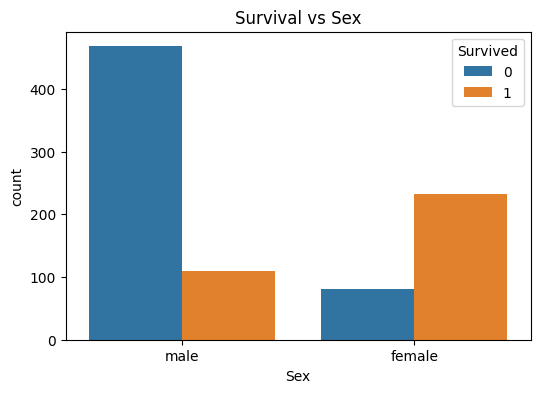

In [20]:
# Survival vs Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df_copy)
plt.title('Survival vs Sex')
plt.show()

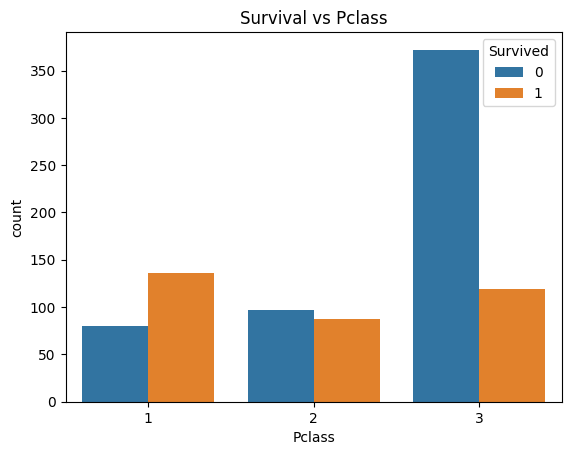

In [21]:
#survival vs pclass
sns.countplot(x='Pclass', hue='Survived', data=df_copy)
plt.title('Survival vs Pclass')
plt.show()

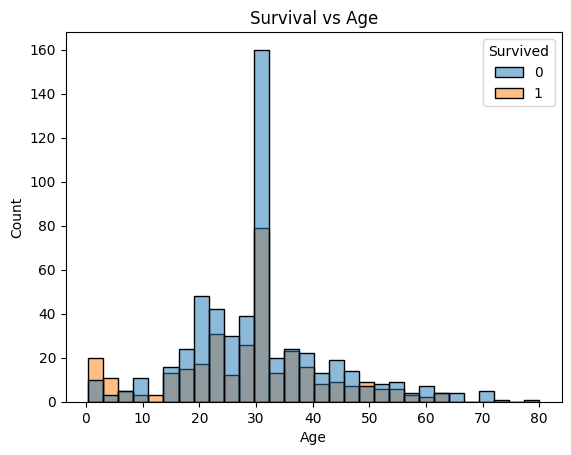

In [22]:
#Survived vs AGe
sns.histplot(x='Age', hue='Survived', data=df_copy)
plt.title('Survival vs Age')
plt.show()

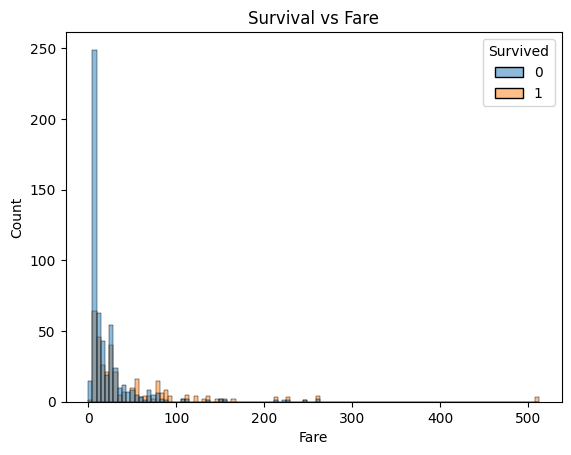

In [23]:
#survided vs fare
sns.histplot(x='Fare', hue='Survived', data=df_copy)
plt.title('Survival vs Fare')
plt.show()

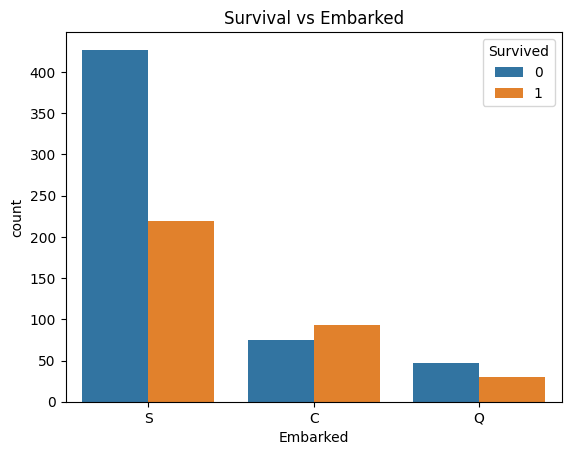

In [24]:
#survived vs embarked
sns.countplot(x='Embarked', hue='Survived', data=df_copy)
plt.title('Survival vs Embarked')
plt.show()


In [25]:
df_copy = df_copy.rename(columns={'SibSp': 'Siblings','Parch':'Parents'})
df_copy.head()

,Survived,Pclass,Sex,Age,Siblings,Parents,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,U,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,U,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,U,S


**Finding outliers**

In [26]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

#  Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

#  Define the upper and lower fences
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#  Filter the outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
df_copy = df_copy[(df_copy['Age'] >= lower_bound) & (df_copy['Age'] <= upper_bound)]
#When you drop rows (like removing outliers or filtering data), your row numbers get skipped. For example, if row 4 is deleted, your index goes: 0, 1, 2, 3, 5, 6.Calling
# .reset_index() fixes this by making the row numbers a perfect, unbroken sequence again (0, 1, 2, 3, 4, 5).

**Featrue Engenerring**

In [27]:
# creating is alone column
df_copy['IsAlone'] =(df_copy['Parents'] == 0) & (df_copy['Siblings']==0)
df_copy.head()


,Survived,Pclass,Sex,Age,Siblings,Parents,Ticket,Fare,Cabin,Embarked,IsAlone
0,0,3,male,22.0,1,0,A/5 21171,7.2500,U,S,False
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,True
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False
4,0,3,male,35.0,0,0,373450,8.0500,U,S,True


In [28]:
# removing tickit cause it does not give much value in pridicting and using fare we can any way pridict the tickets
df_copy = df_copy.drop(columns='Ticket')

In [29]:
df_copy.sample(5)

,Survived,Pclass,Sex,Age,Siblings,Parents,Fare,Cabin,Embarked,IsAlone
74,1,3,male,32.0,0,0,56.4958,U,S,True
178,0,2,male,30.0,0,0,13.0000,U,S,True
804,1,3,male,27.0,0,0,6.9750,U,S,True
111,0,3,female,14.5,1,0,14.4542,U,C,False
614,0,3,male,35.0,0,0,8.0500,U,S,True


In [30]:
# first lable incodeing sex , isalone
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy['Sex'] = le.fit_transform(df_copy['Sex'])
df_copy['IsAlone'] = le.fit_transform(df_copy['IsAlone'])
df_copy.head()

,Survived,Pclass,Sex,Age,Siblings,Parents,Fare,Cabin,Embarked,IsAlone
0,0,3,1,22.0,1,0,7.2500,U,S,0
1,1,1,0,38.0,1,0,71.2833,C85,C,0
2,1,3,0,26.0,0,0,7.9250,U,S,1
3,1,1,0,35.0,1,0,53.1000,C123,S,0
4,0,3,1,35.0,0,0,8.0500,U,S,1


In [31]:
df_copy['Cabin'].unique()

array(['U', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'C52', 'B28', 'C83', 'F33', 'F G73',
       'E31', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101', 'F E69', 'D47',
       'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4', 'A32', 'B4',
       'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35', 'C87', 'B77',
       'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19', 'B49', 'D',
       'C22 C26', 'C106', 'C65', 'E36', 'C54', 'B57 B59 B63 B66', 'C7',
       'E34', 'C32', 'B18', 'C124', 'C91', 'E40', 'T', 'C128', 'D37',
       'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44', 'A34', 'C104',
       'C111', 'C92', 'D21', 'E12', 'E63', 'A14', 'B37', 'C30', 'D20',
       'B79', 'E25', 'D46', 'B73', 'C95', 'B38', 'B39', 'B22', 'C86',
       'C70', 'A16', 'C101', 'C68', 'A10', 'E68', 'B41', 'A20', 'D19',
       'D50', 'D9', 'B50', 'A26', 'D48', 'E58', 'C126', 'B71',
       'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63', 'C62 C64', 'E24',
       'C90', 'C45', 'E8',

In [32]:
# one hot encoding for Cabin , Embarked
#extracting the first element in cabin to get the deck no like deck c,d,e etc
df_copy['Deck'] = df_copy['Cabin'].str[0]
df_encoded = pd.get_dummies(df_copy,columns=['Deck','Embarked'],dtype = int)
df_encoded.head()

,Survived,Pclass,Sex,Age,Siblings,Parents,Fare,Cabin,IsAlone,Deck_A,...,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,U,0,0,...,0,0,0,0,0,0,1,0,0,1
1,1,1,0,38.0,1,0,71.2833,C85,0,0,...,1,0,0,0,0,0,0,1,0,0
2,1,3,0,26.0,0,0,7.9250,U,1,0,...,0,0,0,0,0,0,1,0,0,1
3,1,1,0,35.0,1,0,53.1000,C123,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,3,1,35.0,0,0,8.0500,U,1,0,...,0,0,0,0,0,0,1,0,0,1


In [33]:
df_encoded = df_encoded.drop(columns='Cabin')

In [34]:
df_encoded

,Survived,Pclass,Sex,Age,Siblings,Parents,Fare,IsAlone,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.000000,1,0,7.2500,0,0,0,0,0,0,0,0,0,1,0,0,1
1,1,1,0,38.000000,1,0,71.2833,0,0,0,1,0,0,0,0,0,0,1,0,0
2,1,3,0,26.000000,0,0,7.9250,1,0,0,0,0,0,0,0,0,1,0,0,1
3,1,1,0,35.000000,1,0,53.1000,0,0,0,1,0,0,0,0,0,0,0,0,1
4,0,3,1,35.000000,0,0,8.0500,1,0,0,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,1,0,0,0,0,0,0,0,0,1,0,0,1
887,1,1,0,19.000000,0,0,30.0000,1,0,1,0,0,0,0,0,0,0,0,0,1
888,0,3,0,29.699118,1,2,23.4500,0,0,0,0,0,0,0,0,0,1,0,0,1
889,1,1,1,26.000000,0,0,30.0000,1,0,0,1,0,0,0,0,0,0,1,0,0


# **Usually sensitive to scaling**

**These generally benefit significantly from scaling:**

K-Nearest Neighbors (KNN)

K-Means

Support Vector Machines (SVM)

Logistic Regression

Linear Regression — especially for optimization/regularization

Neural Networks

PCA

# **Usually don't care much about scaling**

**Tree-based algorithms generally don't require feature scaling:**

Decision Tree

Random Forest

XGBoost

LightGBM

CatBoost

In [35]:
df_scaled = df_encoded.copy()

In [36]:
# scaling age and fare for knn , kmeans or etc other model that needs it
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
df_scaled[['Sclaed_Age','Scaled_Fare']] = scalar.fit_transform(df_scaled[['Age','Fare']])

In [37]:
df_scaled = df_scaled.drop(columns=['Age','Fare'])

In [38]:
df_scaled.head()

,Survived,Pclass,Sex,Siblings,Parents,IsAlone,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_C,Embarked_Q,Embarked_S,Sclaed_Age,Scaled_Fare
0,0,3,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,-0.586925,-0.500783
1,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0.717680,0.782122
2,1,3,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,-0.260774,-0.487259
3,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0.473066,0.417820
4,0,3,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0.473066,-0.484755


In [39]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop(columns='Survived')
y = df_encoded['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 6. Model Training and Evaluation

In [40]:
# Redefine x and y using the scaled data for models sensitive to scaling
x_scaled = df_scaled.drop(columns='Survived')
y_scaled = df_scaled['Survived']

# Split the scaled data into training and testing sets
from sklearn.model_selection import train_test_split
x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

print("Scaled data split into training and testing sets.")

Scaled data split into training and testing sets.


### Logistic Regression Model

In [41]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets

# Train the model
log_reg_model.fit(x_train_scaled, y_train_scaled)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(x_test_scaled)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_scaled, y_pred_lr):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_scaled, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test_scaled, y_pred_lr))

Logistic Regression Model Evaluation:
Accuracy: 0.84

Confusion Matrix:
 [[98  8]
 [20 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.88       106
           1       0.86      0.71      0.78        70

    accuracy                           0.84       176
   macro avg       0.85      0.82      0.83       176
weighted avg       0.84      0.84      0.84       176



### Decision Tree Classifier

In [42]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(x_train_scaled, y_train_scaled)

# Make predictions on the test set
y_pred_dt = dt_model.predict(x_test_scaled)

# Evaluate the model
print("Decision Tree Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_scaled, y_pred_dt):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_scaled, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test_scaled, y_pred_dt))

Decision Tree Classifier Model Evaluation:
Accuracy: 0.77

Confusion Matrix:
 [[87 19]
 [22 48]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81       106
           1       0.72      0.69      0.70        70

    accuracy                           0.77       176
   macro avg       0.76      0.75      0.76       176
weighted avg       0.77      0.77      0.77       176

